Carico CIFAR-10 e preparo uno split federato non-IID (pochi label per client).
Confronto tre strategie: FedAvg, FedAvg-Scalar (peso client), FedAvg-Channel (conv3 per-canale via gradiente su attivazioni).

Round 1/50: training locale e calcolo importanza canali su conv3 per guidare l’aggregazione.
  Client 0: classi principali ['dog', 'cat'], esempi=4000, indice_importanza=0.001945
  Client 1: classi principali ['ship', 'dog'], esempi=4000, indice_importanza=0.000690
  Client 2: classi principali ['deer', 'bird'], esempi=4000, indice_importanza=0.001829
  Client 3: classi principali ['cat', 'horse'], esempi=4000, indice_importanza=0.001670
  Client 4: classi principali ['bird', 'dog'], esempi=3000, indice_importanza=0.001597
Aggrego e valuto sul test: confronto diretto tra strategie, stesso round.
  FedAvg               | loss=5.9337 | acc=0.0976
  FedAvg-Scalar        | loss=5.2704 | acc=0.0994
  FedAvg-Channel(conv3)| loss=4.2965 | acc=0.1024

Round 2/50: training locale e calcolo im

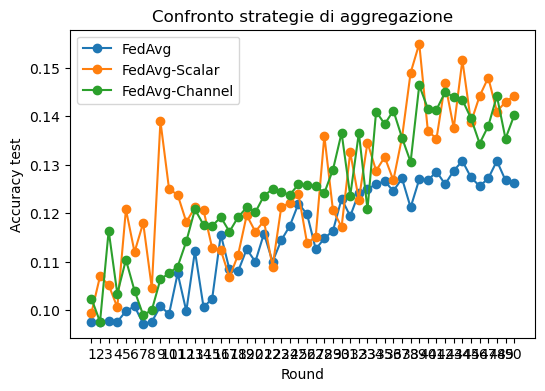

In [10]:
import importlib, sys, subprocess, contextlib, io, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
from torchvision import transforms

def _ensure(pkg, import_name=None):
    name = import_name if import_name is not None else pkg
    try:
        importlib.import_module(name)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

def _silent(fn):
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
        return fn()

_ensure("datasets")
from datasets import load_dataset
from datasets.utils.logging import set_verbosity_error
try:
    from datasets.utils.logging import disable_progress_bar
    disable_progress_bar()
except Exception:
    pass
set_verbosity_error()

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mean = [0.5, 0.5, 0.5]
std = [0.5, 0.5, 0.5]
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])

class HFCifar10Dataset(Dataset):
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform
    def __len__(self):
        return len(self.hf_split)
    def __getitem__(self, idx):
        ex = self.hf_split[int(idx)]
        x = self.transform(ex["img"])
        y = ex["label"]
        return x, y

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def evaluate(model, dl):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0
    crit = nn.CrossEntropyLoss()
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = crit(logits, yb)
            pred = logits.argmax(dim=1)
            correct += int((pred == yb).sum().item())
            total += xb.size(0)
            loss_sum += float(loss.item()) * xb.size(0)
    return loss_sum / max(total, 1), correct / max(total, 1)

def local_train(model, dl, epochs=1, lr=1e-3):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
    return model

def get_state_dict(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def load_state_dict(model, sd):
    model.load_state_dict({k: v.to(next(model.parameters()).device) for k, v in sd.items()})

def aggregate_fedavg(client_sds, client_sizes):
    total = float(sum(client_sizes))
    w = [s / total for s in client_sizes]
    keys = list(client_sds[0].keys())
    out = {}
    for k in keys:
        acc = None
        for i in range(len(client_sds)):
            term = client_sds[i][k] * w[i]
            acc = term if acc is None else (acc + term)
        out[k] = acc
    return out

def aggregate_scalar(client_sds, client_sizes, client_scalar):
    weights = np.array(client_sizes, dtype=np.float64) * np.array(client_scalar, dtype=np.float64)
    if weights.sum() <= 0:
        weights = np.array(client_sizes, dtype=np.float64)
    weights = weights / weights.sum()
    keys = list(client_sds[0].keys())
    out = {}
    for k in keys:
        acc = None
        for i in range(len(client_sds)):
            term = client_sds[i][k] * float(weights[i])
            acc = term if acc is None else (acc + term)
        out[k] = acc
    return out

def aggregate_channel_conv3(client_sds, client_sizes, client_channel_imp):
    total = float(sum(client_sizes))
    w_base = np.array([s / total for s in client_sizes], dtype=np.float64)

    keys = list(client_sds[0].keys())
    out = {}
    for k in keys:
        if k not in ["conv3.weight", "conv3.bias"]:
            acc = None
            for i in range(len(client_sds)):
                term = client_sds[i][k] * float(w_base[i])
                acc = term if acc is None else (acc + term)
            out[k] = acc

    C = int(client_sds[0]["conv3.weight"].shape[0])
    imp = np.stack([np.asarray(v, dtype=np.float64).reshape(-1) for v in client_channel_imp], axis=0)
    if imp.shape[1] != C:
        raise RuntimeError(f"Importanza canali con dimensione sbagliata: atteso C={C}, ottenuto {imp.shape[1]}.")
    imp = np.maximum(imp, 0.0)
    imp_sum = imp.sum(axis=0, keepdims=True)
    imp = np.where(imp_sum > 0, imp / imp_sum, np.ones_like(imp) / imp.shape[0])

    convW = torch.zeros_like(client_sds[0]["conv3.weight"])
    convB = torch.zeros_like(client_sds[0]["conv3.bias"])
    for oc in range(C):
        ww = w_base * imp[:, oc]
        if ww.sum() <= 0:
            ww = w_base
        ww = ww / ww.sum()
        for i in range(len(client_sds)):
            convW[oc] += client_sds[i]["conv3.weight"][oc] * float(ww[i])
            convB[oc] += client_sds[i]["conv3.bias"][oc] * float(ww[i])
    out["conv3.weight"] = convW
    out["conv3.bias"] = convB
    return out

def compute_channel_importance_gradconv(model, dl, n_batches=2):
    model.eval()
    ch_acc = None
    n = 0

    def forward_to_conv3(x):
        x = model.pool1(F.relu(model.conv1(x)))
        x = model.pool2(F.relu(model.conv2(x)))
        x = model.pool3(F.relu(model.conv3(x)))
        return x

    it = iter(dl)
    crit = nn.CrossEntropyLoss(reduction="sum")

    for _ in range(n_batches):
        try:
            xb, yb = next(it)
        except StopIteration:
            break
        xb = xb.to(device)
        yb = yb.to(device)

        with torch.enable_grad():
            xb = xb.detach().requires_grad_(True)
            a = forward_to_conv3(xb)
            a.retain_grad()
            z = model.gap(a)
            z = z.view(z.size(0), -1)
            logits = model.fc(z)
            loss = crit(logits, yb)
            model.zero_grad(set_to_none=True)
            loss.backward()

            g = a.grad.detach()
            v = g.abs().mean(dim=(0, 2, 3))

        if ch_acc is None:
            ch_acc = v
        else:
            ch_acc = ch_acc + v
        n += 1

    if ch_acc is None:
        C = int(model.conv3.weight.shape[0])
        return np.ones((C,), dtype=np.float32), 1.0

    ch = (ch_acc / max(n, 1)).detach().cpu().numpy().astype(np.float32)
    scalar = float(np.mean(ch))
    return ch, scalar

print("Carico CIFAR-10 e preparo uno split federato non-IID (pochi label per client).")
train_hf = _silent(lambda: load_dataset("cifar10", split="train"))
test_hf = _silent(lambda: load_dataset("cifar10", split="test"))
classes = train_hf.features["label"].names

train_ds = HFCifar10Dataset(train_hf, tf)
test_ds = HFCifar10Dataset(test_hf, tf)

test_subset = 5000
test_dl = DataLoader(Subset(test_ds, list(range(test_subset))), batch_size=256, shuffle=False, num_workers=0, pin_memory=False)

num_clients = 5
samples_per_client = 4000
client_classes = 2

labels = np.array([train_hf[i]["label"] for i in range(len(train_hf))], dtype=np.int64)
idx_by_class = [np.where(labels == c)[0].tolist() for c in range(10)]
for c in range(10):
    random.shuffle(idx_by_class[c])

client_indices = []
client_class_sets = []
ptr = [0] * 10
for i in range(num_clients):
    chosen = random.sample(range(10), client_classes)
    client_class_sets.append(chosen)
    per_class = samples_per_client // client_classes
    inds = []
    for c in chosen:
        start = ptr[c]
        end = min(ptr[c] + per_class, len(idx_by_class[c]))
        inds.extend(idx_by_class[c][start:end])
        ptr[c] = end
    random.shuffle(inds)
    client_indices.append(inds)

def make_client_loaders(indices, batch_size=64):
    ds = Subset(train_ds, indices)
    n = len(ds)
    split = max(1, int(0.9 * n))
    train_idx = list(range(split))
    val_idx = list(range(split, n))
    train_dl = DataLoader(Subset(ds, train_idx), batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
    val_dl = DataLoader(Subset(ds, val_idx), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
    return train_dl, val_dl, n

client_loaders = [make_client_loaders(client_indices[i]) for i in range(num_clients)]

print("Confronto tre strategie: FedAvg, FedAvg-Scalar (peso client), FedAvg-Channel (conv3 per-canale via gradiente su attivazioni).")
rounds = 50
local_epochs = 1
lr = 1e-3

global_fedavg = SimpleCNN(10).to(device)
global_scalar = SimpleCNN(10).to(device)
global_channel = SimpleCNN(10).to(device)

init_sd = get_state_dict(global_fedavg)
load_state_dict(global_scalar, init_sd)
load_state_dict(global_channel, init_sd)

history = {"fedavg": [], "scalar": [], "channel": []}

for r in range(1, rounds + 1):
    print(f"\nRound {r}/{rounds}: training locale e calcolo importanza canali su conv3 per guidare l’aggregazione.")
    client_sds_fedavg = []
    client_sds_scalar = []
    client_sds_channel = []
    client_sizes = []
    client_scalar = []
    client_channel_imp = []

    for i in range(num_clients):
        train_dl, val_dl, n = client_loaders[i]
        client_sizes.append(n)

        m_fa = SimpleCNN(10).to(device)
        m_sc = SimpleCNN(10).to(device)
        m_ch = SimpleCNN(10).to(device)

        load_state_dict(m_fa, get_state_dict(global_fedavg))
        load_state_dict(m_sc, get_state_dict(global_scalar))
        load_state_dict(m_ch, get_state_dict(global_channel))

        m_fa = local_train(m_fa, train_dl, epochs=local_epochs, lr=lr)
        m_sc = local_train(m_sc, train_dl, epochs=local_epochs, lr=lr)
        m_ch = local_train(m_ch, train_dl, epochs=local_epochs, lr=lr)

        ch_imp, sc = compute_channel_importance_gradconv(m_ch, val_dl, n_batches=2)
        client_channel_imp.append(ch_imp)
        client_scalar.append(sc)

        client_sds_fedavg.append(get_state_dict(m_fa))
        client_sds_scalar.append(get_state_dict(m_sc))
        client_sds_channel.append(get_state_dict(m_ch))

        print(f"  Client {i}: classi principali {[classes[c] for c in client_class_sets[i]]}, esempi={n}, indice_importanza={sc:.6f}")

    print("Aggrego e valuto sul test: confronto diretto tra strategie, stesso round.")
    sd_fedavg = aggregate_fedavg(client_sds_fedavg, client_sizes)
    sd_scalar = aggregate_scalar(client_sds_scalar, client_sizes, client_scalar)
    sd_channel = aggregate_channel_conv3(client_sds_channel, client_sizes, client_channel_imp)

    load_state_dict(global_fedavg, sd_fedavg)
    load_state_dict(global_scalar, sd_scalar)
    load_state_dict(global_channel, sd_channel)

    loss_fa, acc_fa = evaluate(global_fedavg, test_dl)
    loss_sc, acc_sc = evaluate(global_scalar, test_dl)
    loss_ch, acc_ch = evaluate(global_channel, test_dl)

    history["fedavg"].append(acc_fa)
    history["scalar"].append(acc_sc)
    history["channel"].append(acc_ch)

    print(f"  FedAvg               | loss={loss_fa:.4f} | acc={acc_fa:.4f}")
    print(f"  FedAvg-Scalar        | loss={loss_sc:.4f} | acc={acc_sc:.4f}")
    print(f"  FedAvg-Channel(conv3)| loss={loss_ch:.4f} | acc={acc_ch:.4f}")

print("\nAccuracy per round:")
print("FedAvg        :", [f"{x:.4f}" for x in history["fedavg"]])
print("FedAvg-Scalar :", [f"{x:.4f}" for x in history["scalar"]])
print("FedAvg-Channel:", [f"{x:.4f}" for x in history["channel"]])

best = max(
    [("FedAvg", history["fedavg"][-1]), ("FedAvg-Scalar", history["scalar"][-1]), ("FedAvg-Channel", history["channel"][-1])],
    key=lambda t: t[1]
)
print(f"\nMigliore all’ultimo round: {best[0]} con acc={best[1]:.4f}")

plt.figure(figsize=(6,4))
plt.plot(history["fedavg"], marker="o")
plt.plot(history["scalar"], marker="o")
plt.plot(history["channel"], marker="o")
plt.xticks(list(range(rounds)), [str(i) for i in range(1, rounds+1)])
plt.xlabel("Round")
plt.ylabel("Accuracy test")
plt.legend(["FedAvg", "FedAvg-Scalar", "FedAvg-Channel"])
plt.title("Confronto strategie di aggregazione")
plt.show()